<a href="https://colab.research.google.com/github/nichmars/Test/blob/main/MedianPercentChange.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import io
import pandas as pd

# This line will prompt you to select and upload a file from your local machine
uploaded = files.upload()

# Get the name of the uploaded file (assuming only one file is uploaded)
file_name = next(iter(uploaded))

df = pd.read_excel(file_name)



Saving Filtered Data with Subtypes Again (1).xlsx to Filtered Data with Subtypes Again (1).xlsx


In [24]:
df = pd.read_excel(file_name)

df.replace('Single Issue', 'Single Issue Charity', inplace=True)

# List of metrics we want to analyze
metrics = ["Accounts", "Contributions", "Grants", "Assets"]

# Calculate the difference in years for each 'ein' to check for consecutive years
df = df.sort_values(["ein", "Year"])
df["year_diff"] = df.groupby("ein")["Year"].diff()


# Loop through each metric to calculate percent change and predicted values (ignoring non-consecutive years)
for m in metrics:
    pct_col = f"{m.lower()}_pct_change"

    df[pct_col] = df.groupby("ein")[m].pct_change()
    df.loc[df["year_diff"] != 1, pct_col] = None


#df.head(30)

In [25]:
# Compute median growth for each metric by Year, Type, and subtype
median_growth = (
    df
    .groupby(["Year", "Type", "subtype"])
    [[f"{m.lower()}_pct_change" for m in metrics]]
    .median()
    .reset_index()
)

#median_growth["Year"] = median_growth["Year"] + 1

# Rename columns to indicate these are median growth values
median_growth = median_growth.rename(
    columns={
        f"{m.lower()}_pct_change": f"median_{m.lower()}_growth"
        for m in metrics
    }
)

# Merge the median growth values back into the original DataFrame
df = df.merge(
    median_growth,
    on=["Year", "Type", "subtype"],
    how="left"
)

for m in metrics:
    prev_actual = df.groupby("ein")[m].shift(1)
    df[f"predicted_{m.lower()}"] = prev_actual * (1 + df[f"median_{m.lower()}_growth"])


# Use median growth to predict the next year's value for each metric
#for m in metrics:
#    df[f"predicted_{m.lower()}"] = (
#        df[m] / (1 + df[f"median_{m.lower()}_growth"])
#    )

predictions = df.copy()
predictions["Year"] = predictions["Year"] + 1

In [ ]:
#df.head()

In [ ]:
#df.to_excel(
    #"Attempt_at_Imputing.xlsx",
    #index=False
#)



In [31]:
import numpy as np

# Convert predicted columns to numeric and replace invalid values
pred_cols = ["predicted_accounts", "predicted_contributions",  "predicted_grants", "predicted_assets"]

for col in pred_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.replace([np.inf, -np.inf], np.nan)

# Function to calculate relative error for a column
def relative_error(actual_col, predicted_col):
    valid_rows = df[df[predicted_col].notna()]
    total_actual = valid_rows[actual_col].sum()
    total_predicted = valid_rows[predicted_col].sum()
    RE = (total_actual - total_predicted) / total_actual
    return RE

# Compute relative errors
RE_account = relative_error("Accounts", "predicted_accounts")
RE_contributions = relative_error("Contributions", "predicted_contributions")
RE_grants = relative_error("Grants", "predicted_grants")
RE_assets = relative_error("Assets", "predicted_assets")

print("Relative Error - Account:", abs(RE_account))
print("Relative Error - Contributions:", abs(RE_contributions))
print("Relative Error - Grants:", abs(RE_grants))
print("Relative Error - Assets:", abs(RE_assets))


Relative Error - Account: 0.02162707589157681
Relative Error - Contributions: 0.04922257218841983
Relative Error - Grants: 0.029227155181924144
Relative Error - Assets: 0.0444785652354767


In [32]:
#calculate error between each ein's actual and predicted

#valid_rows_Account = df[df["predicted_accounts"].notna()]



df["Actual Error Accounts"] = -(df["Accounts"] - df["predicted_accounts"])/df["Accounts"]
df["Actual Error Contributions"] = -(df["Contributions"] - df["predicted_contributions"])/df["Contributions"]
df["Actual Error Grants"] = -(df["Grants"] - df["predicted_grants"])/df["Grants"]
df["Actual Error Assets"] = -(df["Assets"] - df["predicted_assets"])/df["Assets"]


#df["Actual Error Accounts"].min()


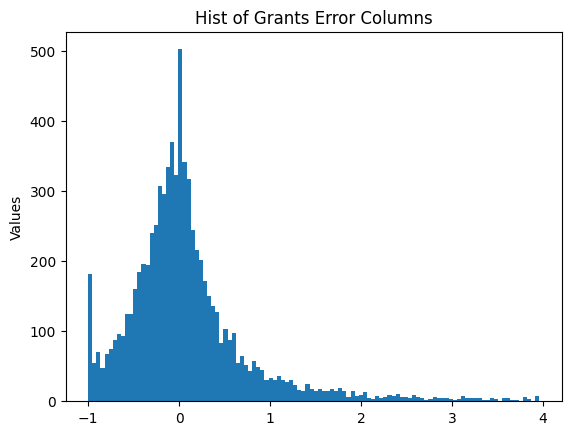

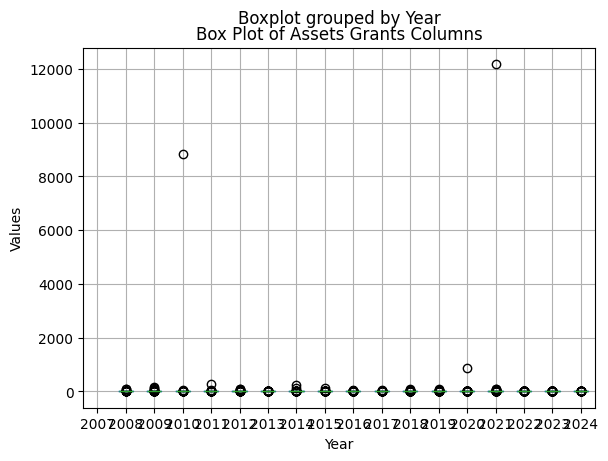

In [34]:
import matplotlib.pyplot as plt

filtered_df = df[~np.isinf(df['Actual Error Grants'])]
cleaned_errors = [x for x in filtered_df['Actual Error Grants'] if not np.isnan(x) and x < 4 ]

#print(cleaned_errors)

#bins_arrayd = np.arange()
plt.hist(cleaned_errors, bins = 110)

plt.title("Hist of Grants Error Columns")
plt.ylabel("Values")
plt.show()

'''df.boxplot(column='Actual Error Contributions', by='Year')

plt.title("Box Plot of Contributions Error Columns")
plt.ylabel("Values")
plt.show()

df.boxplot(column='Actual Error Assets', by='Year')

plt.title("Box Plot of Assets Error Columns")
plt.ylabel("Values")
plt.show()'''

df.boxplot(column='Actual Error Grants', by='Year')

plt.title("Box Plot of Assets Grants Columns")
plt.ylabel("Values")
plt.show()

In [35]:
filtered_df = df[~np.isinf(df['Actual Error Grants'])]
max_score_index = filtered_df['Actual Error Grants'].idxmax()

# Use .loc[] to retrieve the entire row as a Series
max_row = df.loc[max_score_index]

print("\nRow with the maximum Actual Error Grants:")
print(max_row)


Row with the maximum Actual Error Grants:
ein                                       132992977
Year                                           2021
Accounts                                         65
Contributions                              260938.0
Grants                                           16
Assets                                     260938.0
Type                           Single Issue Charity
subtype                                       Other
year_diff                                       1.0
accounts_pct_change                        4.909091
contributions_pct_change                  -0.378868
grants_pct_change                         -0.999918
assets_pct_change                         -0.468569
median_accounts_growth                          0.0
median_contributions_growth                0.122597
median_grants_growth                            0.0
median_assets_growth                       0.174512
predicted_accounts                             11.0
predicted_contributio

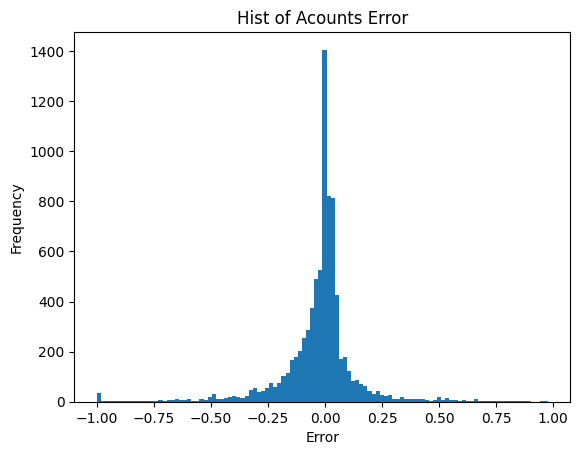

In [36]:
df_error_accounts = df[~np.isinf(df['Actual Error Accounts'])]
cleaned_errors_accounts = [x for x in df_error_accounts['Actual Error Accounts'] if not np.isnan(x) and x < 1 ]

#print(cleaned_errors_accounts)

plt.hist(cleaned_errors_accounts, bins = 110)

plt.title("Hist of Acounts Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

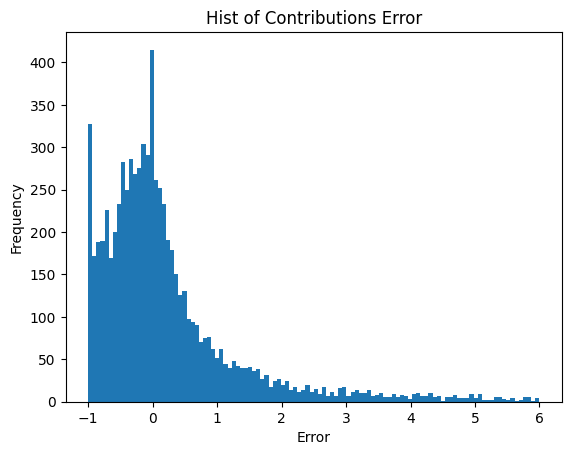

In [37]:
df_error_contributions = df[~np.isinf(df['Actual Error Contributions'])]
cleaned_errors_contributions = [x for x in df_error_contributions['Actual Error Contributions'] if not np.isnan(x) and x < 6 ]

#print(cleaned_errors_contributions)

plt.hist(cleaned_errors_contributions, bins = 110)

plt.title("Hist of Contributions Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

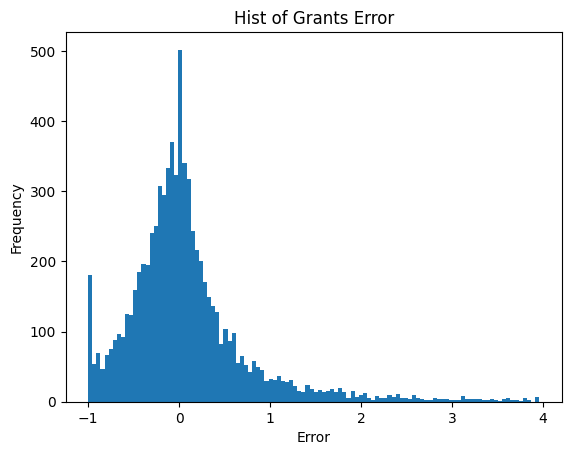

In [38]:
df_error_grants = df[~np.isinf(df['Actual Error Grants'])]
cleaned_errors_grants = [x for x in df_error_grants['Actual Error Grants'] if not np.isnan(x) and x < 4 ]

#print(cleaned_errors_grants)

plt.hist(cleaned_errors_grants, bins = 110)

plt.title("Hist of Grants Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

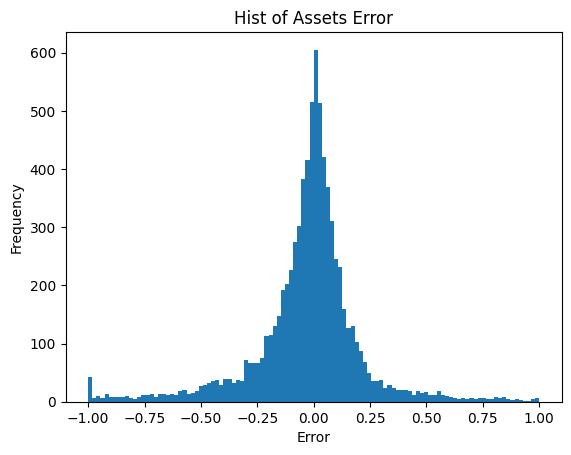

In [39]:
df_error_assets = df[~np.isinf(df['Actual Error Assets'])]
cleaned_errors_assets = [x for x in df_error_assets['Actual Error Assets'] if not np.isnan(x) and x < 1 ]

#print(cleaned_errors_assets)

plt.hist(cleaned_errors_assets, bins = 110)

plt.title("Hist of Assets Error")
plt.ylabel("Frequency")
plt.xlabel("Error")
plt.show()

In [46]:
unique_names = df['Type'].unique()
unique_names2 = df['subtype'].unique()
print(unique_names, unique_names2)

['Community Foundation' 'Single Issue Charity' 'National'] ['Community' 'Other' 'Donation Processor' 'Standard'
 'Religiously-Affiliated' 'Universities and Healthcare']


In [48]:
Uniques = df.groupby('Type')['subtype'].unique()


print(Uniques['National'])

['Donation Processor' 'Standard' 'Other']
